# Playground

In [485]:
import geopandas as gpd
import osmnx
import pandas as pd
import shapely
from shapely.geometry.linestring import LineString
from shapely.ops import unary_union, split
import networkx as nx
import osmnx as ox
import momepy
import matplotlib.pyplot as plt
import contextily as cx
from scipy.spatial import KDTree

In [486]:
def plot_maps(*maps):
    fig, ax = plt.subplots()
    for map, color in maps:
        map.plot(ax=ax, color=color)
    cx.add_basemap(ax=ax, crs=maps[0][0].crs, source=cx.providers.CartoDB.Positron)
    plt.show()

## Validate CRS function

In [487]:
def validate_crs(gdf):
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=4326)
        gdf = gdf.to_crs(gdf.estimate_utm_crs())
    if not gdf.crs:
        gdf = gdf.set_crs(epsg=4326)
        gdf = gdf.to_crs(gdf.estimate_utm_crs())
    return gdf.crs

## Centroid function

In [488]:
def get_centroids(gdf):
    crs = validate_crs(gdf)
    gdf = gdf.to_crs(crs)
    gdf['shape_centroid'] = gdf.geometry.centroid
    return gdf

In [489]:
gdf_shape = gpd.read_file('test_shapes.gpkg')
get_centroids(gdf_shape)

,id,feat,geometry,shape_centroid
0,1,first,"MULTIPOLYGON (((322109.431 4730357.405, 322255...",POINT (321816.211 4730103.326)
1,2,second,"MULTIPOLYGON (((322535.551 4730198.913, 322504...",POINT (322622.382 4730293.955)
2,3,third,"MULTIPOLYGON (((322285.486 4729706.411, 322224...",POINT (322362.492 4729893.569)


## Segment function

In [490]:
def preprocess_route(gdf_polylines):
    crs = validate_crs(gdf_polylines)
    gdf_polylines = gdf_polylines.to_crs(crs)

    segmented_lines = unary_union(gdf_polylines.geometry)
    segmented_lines = shapely.get_parts(segmented_lines)
    segments = []
    for line in segmented_lines:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            segments.append(shapely.geometry.LineString([coords[i], coords[i + 1]]))

    return gpd.GeoDataFrame(geometry=segments, crs=crs)

In [491]:
_route = gpd.read_file('test_lines2.gpkg')
preprocess_route(_route).geometry

0     LINESTRING (322140.932 4730394.071, 322234.37 ...
1     LINESTRING (322234.37 4730493.546, 322314.936 ...
2     LINESTRING (322314.936 4730579.318, 322544.927...
3     LINESTRING (322544.927 4730381.365, 322462.129...
4     LINESTRING (322462.129 4730299.918, 322298.947...
5     LINESTRING (322298.947 4730139.397, 321424.348...
6     LINESTRING (321424.348 4729770.724, 321395.375...
7     LINESTRING (321395.375 4729832.373, 321449.876...
8     LINESTRING (321449.876 4730126.306, 321489.203...
9     LINESTRING (321489.203 4730338.405, 321507.324...
10    LINESTRING (321446.182 4730344.025, 321489.203...
11    LINESTRING (321489.203 4730338.405, 321624.421...
12    LINESTRING (321624.421 4730320.743, 321781.21 ...
13    LINESTRING (321781.21 4730300.262, 321795.727 ...
14    LINESTRING (321795.727 4730407.63, 321884.513 ...
15    LINESTRING (321884.513 4730386.608, 321899.872...
16    LINESTRING (321899.872 4730435.399, 322002.69 ...
17    LINESTRING (322002.69 4730503.02, 322099.4

## Snap targets to route function



In [492]:
def extend_route_to_centroids(route, objects):
    crs = validate_crs(route)
    route = route.to_crs(crs)
    objects = objects.to_crs(crs)

    _ = route.sindex
    _ = objects.sindex

    gdf_snapped = gpd.sjoin_nearest(get_centroids(objects), route, how='left')[['shape_centroid', 'index_right']].drop_duplicates(subset='shape_centroid')
    gdf_snapped = gdf_snapped.merge(route[['geometry']], left_on='index_right', right_index=True)
    gdf_snapped['start_line'] = gdf_snapped['geometry'].interpolate(gdf_snapped['geometry'].project(gdf_snapped['shape_centroid']))
    new_geometries = [LineString([pt1, pt2]) for pt1, pt2 in zip(gdf_snapped['start_line'], gdf_snapped['shape_centroid'])]
    new_gdf = gpd.GeoDataFrame(geometry=new_geometries, crs=crs)
    return pd.concat([route, new_gdf], ignore_index=True)


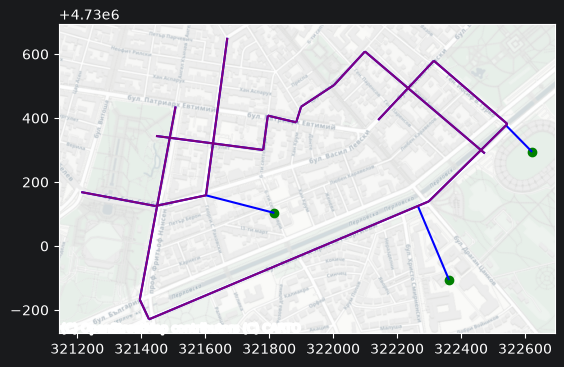

In [493]:
snapped_targets = extend_route_to_centroids(preprocess_route(_route), get_centroids(gdf_shape))
# snapped_targets
plot_maps((snapped_targets, 'blue'), (get_centroids(gdf_shape)['shape_centroid'], 'green'), (preprocess_route(_route), 'purple'))

In [494]:
# Start Here

## Segment line with snapped points function

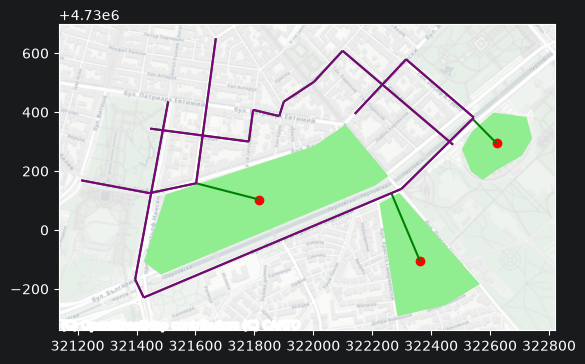

In [495]:
_lines = gpd.read_file('test_lines2.gpkg')
_shape = gpd.read_file('test_shapes.gpkg')

_route = preprocess_route(_lines)
_route = extend_route_to_centroids(_route, _shape)
_route = preprocess_route(_route)

plot_maps((_route, 'green'), (_shape, 'lightgreen'), (preprocess_route(_lines), 'purple'), (_shape.centroid, 'red'))

In [496]:
_route_graph = momepy.gdf_to_nx(_route, approach='primal', length='length', directed=True)
_node_ids = list(_route_graph.nodes)
_node_coords = [node for node in _node_ids]  # coordinates are keys in momepy primal graph
_spatial_index = KDTree(_node_coords)

## Create isochrones function

In [497]:
def create_isochrones(graph, starting_point, distance, spatial_index, node_ids):
    _, min_idx = spatial_index.query([starting_point.x, starting_point.y])
    nearest_node = node_ids[min_idx]

    isochrone = nx.ego_graph(graph, nearest_node, radius=distance, distance='length', undirected=True)
    isochrone = ox.graph_to_gdfs(isochrone, nodes=False, edges=True)

    return isochrone

### testing polyline graph

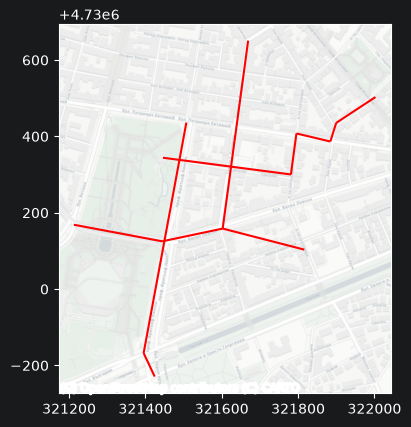

In [498]:
i = create_isochrones(_route_graph, _shape.centroid.iloc[0], 1000, _spatial_index, _node_ids)
plot_maps((i, 'red'))

In [499]:
i.crs

<Projected CRS: EPSG:7801>
Name: BGS2005 / CCS2005
Axis Info [cartesian]:
- x[north]: Northing (metre)
- y[east]: Easting (metre)
Area of Use:
- name: Bulgaria - onshore.
- bounds: (22.36, 41.24, 28.68, 44.23)
Coordinate Operation:
- name: Cadastral Coordinate System 2005
- method: Lambert Conic Conformal (2SP)
Datum: Bulgaria Geodetic System 2005
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### testing OSM graph

In [500]:
route_osm_graph = ox.graph_from_polygon(_shape.to_crs(epsg=4326).iloc[0].geometry, network_type='walk')
route_osm = ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True)
route_osm = momepy.gdf_to_nx(route_osm.to_crs(validate_crs(route_osm)), approach='primal', length='length', directed=True)

node_osm_ids = list(route_osm.nodes)
node_osm_coords = [node for node in node_osm_ids]  # coordinates are keys in momepy primal graph
spatial_osm_index = KDTree(node_osm_coords)

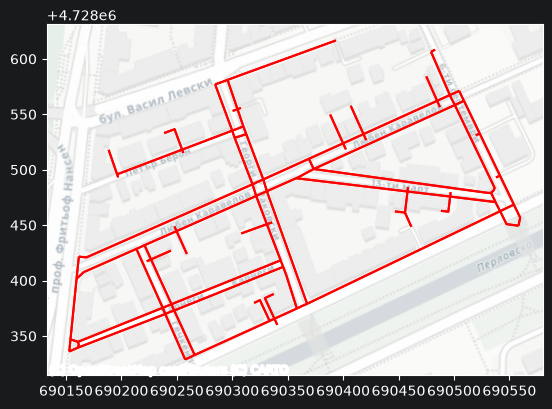

In [501]:
j = create_isochrones(route_osm, _shape.centroid.iloc[0], 500, spatial_osm_index, node_osm_ids)
plot_maps((j, 'red'))
# j = j.reset_index()

In [502]:
type(j)

geopandas.geodataframe.GeoDataFrame

## Accessibility function

In [503]:
_target = gpd.read_file('test_target.gpkg')
# gpd.sjoin_nearest(target, j.to_crs(target.crs), how='left')
_route = extend_route_to_centroids(_route, _target)
_route = preprocess_route(_route)

In [504]:
i = create_isochrones(_route_graph, _shape.centroid.iloc[0], 1000, _spatial_index, _node_ids)

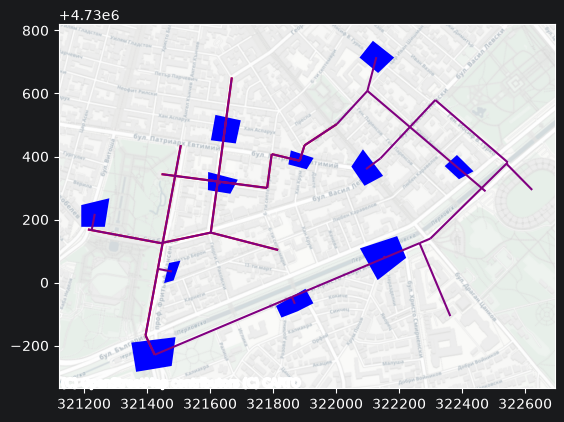

In [505]:
plot_maps((i, 'red'), (_route, 'purple'),  (_target, 'blue'))

In [506]:
i_p = i.buffer(10).union_all()
c = gpd.sjoin(gpd.GeoDataFrame(geometry=[i_p], crs=_target.crs), _target, how='inner', predicate='intersects')
c

,geometry,index_right,type
0,"POLYGON ((321385.952 4729829.027, 321385.903 4...",10,c
0,"POLYGON ((321385.952 4729829.027, 321385.903 4...",9,b
0,"POLYGON ((321385.952 4729829.027, 321385.903 4...",3,a
0,"POLYGON ((321385.952 4729829.027, 321385.903 4...",8,b
0,"POLYGON ((321385.952 4729829.027, 321385.903 4...",2,a


In [507]:
def isochrone_target_intersection(isochrone, *targets):
    crs = validate_crs(isochrone)

    isochrone_buffered = isochrone.buffer(25).union_all()

    count = 0
    for target in targets:
        target = target.to_crs(crs)
        _ = target.sindex
        joined = target[target.geometry.centroid.within(isochrone_buffered)]
        print(joined.shape)
        if joined.shape[0] != 0:
            count += 1

    return count

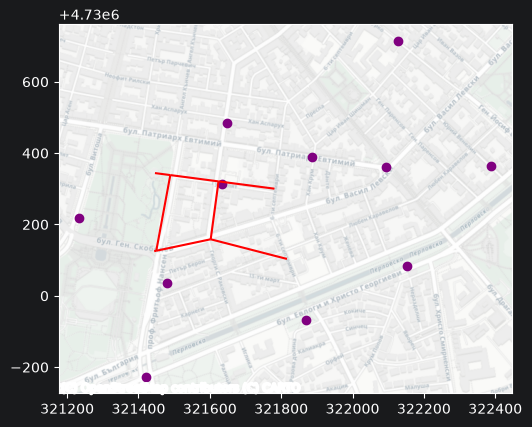

In [508]:
k = create_isochrones(_route_graph, _shape.centroid.iloc[0], 600, _spatial_index, _node_ids)
plot_maps((k, 'red'), (_target.centroid, 'purple'))

In [509]:
isochrone_target_intersection(i, _target[_target['type'] == 'a'], _target[_target['type'] == 'b'], _target[_target['type'] == 'c'])

(2, 2)
(1, 2)
(1, 2)


3

In [510]:
isochrone_target_intersection(k, _target[_target['type'] == 'a'], _target[_target['type'] == 'b'], _target[_target['type'] == 'c'])

(1, 2)
(0, 2)
(0, 2)


1

## Accessibility analysis function

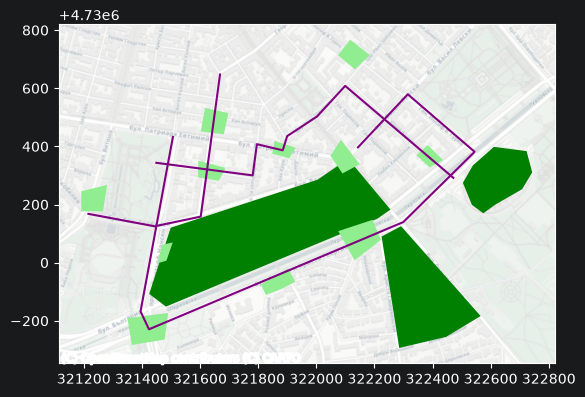

In [511]:
_start = gpd.read_file('test_shapes.gpkg')
_target = gpd.read_file('test_target.gpkg')
_route = gpd.read_file('test_lines2.gpkg')

plot_maps((_start, 'green'), (_target, 'lightgreen'), (_route, 'purple'))

In [512]:
def accessibility_analysis(start, route, distance, *targets):
    crs = validate_crs(route)

    route = preprocess_route(route)
    route = extend_route_to_centroids(route, start)
    route = route.to_crs(crs)
    route = route.to_crs(crs)

    for target in targets:
        target = target.to_crs(crs)
        route = extend_route_to_centroids(route, target)
    start = get_centroids(start)
    start = start.to_crs(crs)

    route = momepy.gdf_to_nx(route, approach='primal', length='length', directed=True)

    node_ids = list(route.nodes)
    node_coords = [node for node in node_ids]
    spatial_index = KDTree(node_coords)
    start['accessibility'] = start.apply(
        lambda row: isochrone_target_intersection(create_isochrones(route,
                                                                    row['shape_centroid'],
                                                                    distance,
                                                                    spatial_index,
                                                                    node_ids), *targets), axis=1)
    return start

In [515]:
_targets = [_target[_target['type'] == 'a'], _target[_target['type'] == 'b'], _target[_target['type'] == 'c']]
_start= accessibility_analysis(_start, _route, 1000, *_targets)

(2, 2)
(1, 2)
(1, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)


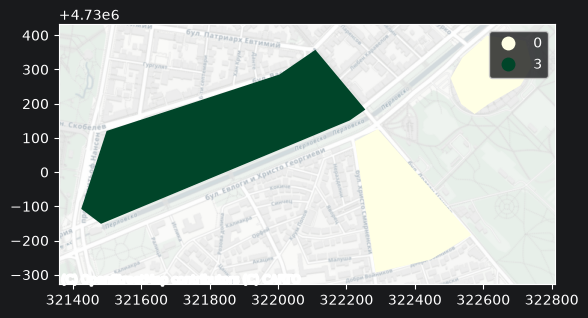

In [516]:
fig, ax = plt.subplots()
_start.plot(ax=ax, column='accessibility', cmap='YlGn', legend=True, categorical=True)
cx.add_basemap(ax=ax, crs=_start.crs, source=cx.providers.CartoDB.Positron)

In [517]:
route_osm_graph = ox.graph_from_polygon(shapely.box(*_shape.to_crs(epsg=4326).total_bounds), network_type='walk')
route_osm = ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True)

In [518]:
start_osm = accessibility_analysis(_start, route_osm, 1000, *_targets)

(4, 2)
(3, 2)
(1, 2)
(4, 2)
(3, 2)
(1, 2)
(4, 2)
(3, 2)
(1, 2)


In [519]:
start_osm

,id,feat,geometry,shape_centroid,accessibility
0,1,first,"MULTIPOLYGON (((690790.612 4728811.794, 690945...",POINT (321816.211 4730103.326),3
1,2,second,"MULTIPOLYGON (((691224.614 4728676.19, 691189....",POINT (322622.382 4730293.955),3
2,3,third,"MULTIPOLYGON (((691001.089 4728171.018, 690920...",POINT (322362.492 4729893.569),3


## Testing OSM api

In [520]:
route_osm_graph = ox.graph_from_polygon(shapely.box(*_shape.to_crs(epsg=4326).total_bounds), network_type='walk')
points = ox.features_from_polygon(shapely.box(*_shape.to_crs(epsg=4326).total_bounds), tags={'building': True})
route_osm_graph = momepy.gdf_to_nx(ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True).to_crs(validate_crs(points)), approach='primal', length='length', directed=True)

In [521]:
node_ids2 = list(route_osm_graph.nodes)
node_coords2 = [node for node in node_ids2]
spatial_index2 = KDTree(node_coords2)

In [522]:
_start = points[points['building'].isin(['apartments'])]
target1 = points[points['building'].isin(['commercial', 'service', 'church'])]
target2 = points[points['building'].isin(['school', 'university', 'kindergarten'])]
target3 = points[points['building'].isin(['restaurant', 'retail'])]

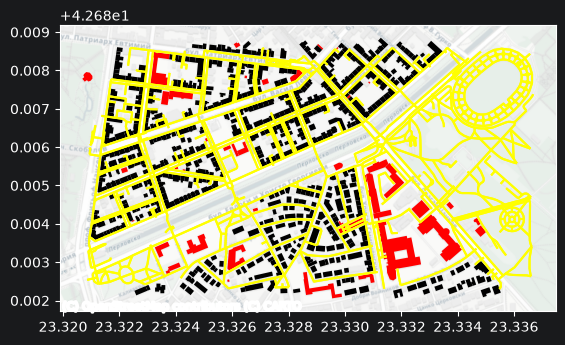

In [523]:
plot_maps(
    (target1, 'red'),
    (target2, 'red'),
    (target3, 'red'),
    (_start, 'black'),
    (route_osm, 'yellow')
)

In [524]:
_start = accessibility_analysis(_start, route_osm, 2500, target1, target2, target3)

(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(1, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(0, 85)
(17, 85)
(11, 85)
(15, 85)
(17, 85)
(11, 85)
(15, 85)
(0, 85)
(0, 85)
(1, 85)
(17, 85)
(11, 85)
(15, 85)
(17, 85)
(11, 85)
(15, 85)
(

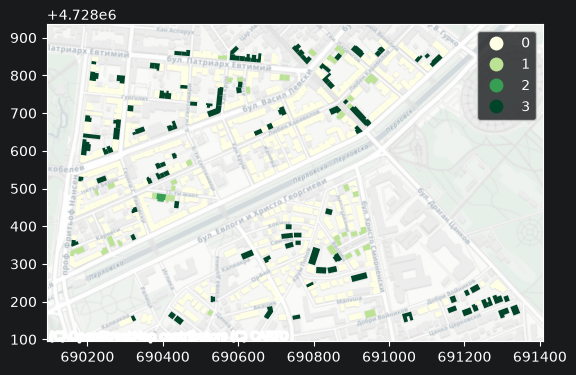

In [527]:
fig, ax = plt.subplots()
_start.plot(ax=ax, column='accessibility', cmap='YlGn', legend=True, categorical=True)
# ox.graph_to_gdfs(_route_ret, nodes=False, edges=True).plot(ax=ax, color='black')
cx.add_basemap(ax=ax, crs=_start.crs, source=cx.providers.CartoDB.Positron)

In [545]:
_start.crs

<Projected CRS: EPSG:32634>
Name: WGS 84 / UTM zone 34N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 18°E and 24°E, northern hemisphere between equator and 84°N, onshore and offshore. Albania. Belarus. Bosnia and Herzegovina. Bulgaria. Central African Republic. Chad. Croatia. Democratic Republic of the Congo (Zaire). Estonia. Finland. Greece. Hungary. Italy. Kosovo. Latvia. Libya. Lithuania. Montenegro. North Macedonia. Norway, including Svalbard and Bjornoys. Poland. Romania. Russian Federation. Serbia. Slovakia. Sudan. Sweden. Ukraine.
- bounds: (18.0, 0.0, 24.0, 84.0)
Coordinate Operation:
- name: UTM zone 34N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [529]:
start2 = accessibility_analysis(_start, route_osm, 1000, _target)

(0, 2)
(0, 2)
(0, 2)
(1, 2)
(11, 2)
(0, 2)
(11, 2)
(0, 2)
(1, 2)
(0, 2)
(0, 2)
(9, 2)
(0, 2)
(1, 2)
(1, 2)
(0, 2)
(0, 2)
(9, 2)
(9, 2)
(0, 2)
(11, 2)
(0, 2)
(10, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(11, 2)
(0, 2)
(0, 2)
(11, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(9, 2)
(9, 2)
(0, 2)
(9, 2)
(9, 2)
(0, 2)
(0, 2)
(11, 2)
(11, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(9, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(10, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(10, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(10, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(9, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(1, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(9, 2)
(8, 2)
(0, 2)
(0, 2)
(0, 2)
(11, 2)
(10, 2)
(10, 2)
(0, 2)
(10, 2)
(10, 2)
(10, 2)
(0, 2)
(0, 2)
(0, 2)
(0, 2)
(1, 2)
(0, 2)
(0, 2)
(11, 2)
(0, 2)
(0, 2)
(11, 2)
(0, 2)
(11, 2)
(0, 2)
(11, 2)
(0, 2)

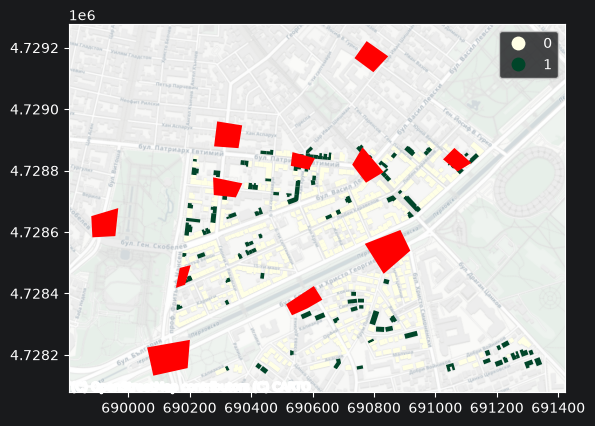

In [532]:
fig, ax = plt.subplots()
start2.plot(ax=ax, column='accessibility', cmap='YlGn', legend=True, categorical=True)
_target.to_crs(start2.crs).plot(ax=ax, color='red')
# ox.graph_to_gdfs(_route_ret, nodes=False, edges=True).plot(ax=ax, color='black')
cx.add_basemap(ax=ax, crs=start2.crs, source=cx.providers.CartoDB.Positron)

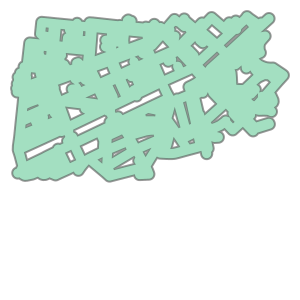

In [547]:
shape = create_isochrones(route_osm_graph, _start['geometry'].iloc[0].centroid, 1000, spatial_index2, node_ids2).buffer(25).union_all()
#
# target1 = target1.to_crs(validate_crs(points))
# target1[target1.centroid.within(shape)]
shape